## OLIST E-COMMERCE PERFORMANCE ANALYSIS
### Business Performance Review using the Olist Brazilian E-Commerce Dataset

## Project Overview

This project analyzes transaction data from Olist — Brazil's largest e-commerce marketplace — to evaluate overall business performance and identify opportunities for improvement across sales, delivery, customer satisfaction, and geographic reach.

The analysis is structured across four key areas:
- **Sales & Revenue Trends** — growth trajectory, top categories, payment behaviour
- **Delivery Performance** — late delivery rate, delay magnitude, impact on satisfaction
- **Customer Satisfaction & Reviews** — review distribution, worst-rated categories
- **Geographic Insights** — state-level revenue, customer concentration, delivery times

**Tools Used:** Python (Pandas, Matplotlib, Seaborn) | MySQL | Power BI  
**Dataset:** [Olist Brazilian E-Commerce — Kaggle](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)  
**Project Type:** End-to-end Exploratory Data Analysis

## Business Problem

Olist operates as a marketplace connecting Brazilian sellers to customers across all 27 states. While the platform has experienced strong revenue growth between 2016 and 2018, several operational and strategic questions remain unanswered:

- Which product categories drive the most revenue — and which underperform?
- What percentage of orders are delivered late, and how severely does this affect customer satisfaction?
- Are there geographic regions that are underserved or disproportionately profitable?
- What payment methods are customers using, and what does this reveal about the customer base?

This analysis investigates these questions using the full 8-table Olist dataset joined into a single master DataFrame.

## Dataset Overview

The dataset used in this project is the **Olist Brazilian E-Commerce dataset**, which contains real anonymized transaction data from 2016 to 2018.

The dataset consists of 8 relational tables:

| Table | Description |
|---|---|
| `olist_orders_dataset` | Order-level data including timestamps and status |
| `olist_order_items_dataset` | Item-level data with product, seller, price and freight |
| `olist_order_payments_dataset` | Payment type and value per order |
| `olist_order_reviews_dataset` | Customer review scores and comments |
| `olist_customers_dataset` | Customer location and unique ID |
| `olist_sellers_dataset` | Seller location data |
| `olist_products_dataset` | Product attributes and category names |
| `product_category_name_translation` | Portuguese to English category name mapping |

All 8 tables were joined into a single master DataFrame for analysis.

## Data Preparation

Before performing analysis, all datasets were loaded, inspected, and merged into a single master DataFrame.

The following preprocessing steps were performed:
- Inspected raw date string format — confirmed `dd-mm-yyyy HH:MM` format in orders table
- Converted all 5 datetime columns in the orders table using the correct format string `'%d-%m-%Y %H:%M'`
- Checked for null values and duplicates across all 8 tables
- Translated product category names from Portuguese to English via the translation table
- Merged all 8 tables into a master DataFrame using left joins on shared keys
- Filtered to delivered orders only for analysis
- Created two derived columns: `delivery_days` (actual delivery duration) and `delay_days` (actual vs estimated delivery date)

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [36]:
orders     = pd.read_csv("D:\DATA ANALYSIS PREP\PROJECT-2\OLIST Datasets\olist_orders_dataset.csv")
items      = pd.read_csv("D:\DATA ANALYSIS PREP\PROJECT-2\OLIST Datasets\olist_order_items_dataset.csv")
payments   = pd.read_csv("D:\DATA ANALYSIS PREP\PROJECT-2\OLIST Datasets\olist_order_payments_dataset.csv")
reviews    = pd.read_csv("D:\DATA ANALYSIS PREP\PROJECT-2\OLIST Datasets\olist_order_reviews_dataset.csv")
customer   = pd.read_csv("D:\DATA ANALYSIS PREP\PROJECT-2\OLIST Datasets\olist_customers_dataset.csv")
seller     = pd.read_csv("D:\DATA ANALYSIS PREP\PROJECT-2\OLIST Datasets\olist_sellers_dataset.csv")
product    = pd.read_csv("D:\DATA ANALYSIS PREP\PROJECT-2\OLIST Datasets\olist_products_dataset.csv")
categories = pd.read_csv("D:\DATA ANALYSIS PREP\PROJECT-2\OLIST Datasets\product_category_name_translation.csv")

In [39]:
# Inspect orders table — shape, dtypes, missing values
print('Shape: ',orders.shape)
print('\n Data Types:\n ',orders.dtypes)
print('\n Missing Values:\n ',orders.isnull().sum())

Shape:  (99441, 8)

 Data Types:
  order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

 Missing Values:
  order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


In [40]:
# Inspect raw date string format before conversion
# Olist dates are stored as dd-mm-yyyy HH:MM — must confirm before parsing
print(orders['order_purchase_timestamp'].head(10))
print('\n Type of First value: ', type(orders['order_purchase_timestamp'].iloc[0]))

0    02-10-2017 10:56
1    24-07-2018 20:41
2    08-08-2018 08:38
3    18-11-2017 19:28
4    13-02-2018 21:18
5    09-07-2017 21:57
6    11-04-2017 12:22
7    16-05-2017 13:10
8    23-01-2017 18:29
9    29-07-2017 11:55
Name: order_purchase_timestamp, dtype: object

 Type of First value:  <class 'str'>


In [41]:
# Convert all date columns in orders using confirmed format string
date_cols = ['order_purchase_timestamp',
             'order_approved_at',
             'order_delivered_carrier_date',
             'order_delivered_customer_date',
             'order_estimated_delivery_date']
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col],format='%d-%m-%Y %H:%M', errors= 'coerce')
print(orders.dtypes)

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


In [43]:
# Confirm date range after conversion
print(orders['order_purchase_timestamp'].min())
print(orders['order_purchase_timestamp'].max())

2016-09-04 21:15:00
2018-10-17 17:30:00


In [44]:
# Null and shape check across all 8 tables
for name, df in [('orders', orders), ('items', items), ('payments', payments),
                 ('reviews', reviews), ('customer', customer), ('seller', seller),
                 ('product', product), ('categories', categories)]:
    print(f'--- {name} ---')
    print('Shape:', df.shape)
    print(df.isnull().sum())
    print()

--- orders ---
Shape: (99441, 8)
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

--- items ---
Shape: (112650, 7)
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

--- payments ---
Shape: (103886, 5)
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

--- reviews ---
Shape: (99224, 7)
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_t

## Data Cleaning & Master DataFrame Construction

In [45]:
# Translate product category names from Portuguese to English
product = product.merge(categories, on='product_category_name', how='left')
print(product[['product_category_name','product_category_name_english']].head(10))

   product_category_name product_category_name_english
0             perfumaria                     perfumery
1                  artes                           art
2          esporte_lazer                sports_leisure
3                  bebes                          baby
4  utilidades_domesticas                    housewares
5  instrumentos_musicais           musical_instruments
6             cool_stuff                    cool_stuff
7       moveis_decoracao               furniture_decor
8       eletrodomesticos               home_appliances
9             brinquedos                          toys


In [46]:
# Build master DataFrame — join all 8 tables on shared keys
master = orders.merge(items, on='order_id', how='left')        # order+item = master
master = master.merge(payments, on='order_id', how='left')     # master + payments
master = master.merge(customer, on='customer_id', how='left')  # master + customer
master = master.merge(product, on='product_id', how='left')    # master + product
master = master.merge(seller, on='seller_id', how='left')      # master + seller
master = master.merge(reviews, on='order_id', how='left')      # master + reviews

print(master.shape)

(119143, 40)


In [48]:
# Filter to delivered orders only — excludes cancelled, unavailable, shipped etc.
delivered = master[master['order_status'] == 'delivered'].copy()
print('Delivered orders shape:', delivered.shape)

Delivered orders shape: (115723, 40)


In [49]:
# Derived column 1 — actual delivery duration in days
delivered['delivery_days'] = (
    delivered['order_delivered_customer_date'] - delivered['order_purchase_timestamp']
).dt.days

In [50]:
# Derived column 2 — delay days 
delivered['delay_days'] = (
    delivered['order_delivered_customer_date'] - delivered['order_estimated_delivery_date']
).dt.days

print(delivered.shape)
print(delivered['delivery_days'].describe())

(115723, 42)
count    115715.000000
mean         12.022642
std           9.454650
min           0.000000
25%           6.000000
50%          10.000000
75%          15.000000
max         209.000000
Name: delivery_days, dtype: float64


## 1. Sales & Revenue Trends

This section examines how revenue evolved over time, which product categories generate the most value, and how customers pay.

Understanding revenue trends is essential for identifying growth periods, seasonal patterns, and category-level priorities for the business.

In [51]:
# Monthly revenue aggregation
monthly_revenue = delivered.groupby(
                        delivered['order_purchase_timestamp'].dt.to_period('M')
                        )['payment_value'].sum()
print(monthly_revenue)

order_purchase_timestamp
2016-09          0.00
2016-10      62185.82
2016-12         19.62
2017-01     178282.10
2017-02     327928.86
2017-03     508767.44
2017-04     457050.31
2017-05     707042.90
2017-06     590223.90
2017-07     720446.68
2017-08     850611.08
2017-09    1003326.07
2017-10    1012420.44
2017-11    1559739.87
2017-12    1023434.55
2018-01    1383865.26
2018-02    1295740.35
2018-03    1441973.39
2018-04    1469136.33
2018-05    1481529.96
2018-06    1286923.47
2018-07    1309951.88
2018-08    1211344.79
Freq: M, Name: payment_value, dtype: float64


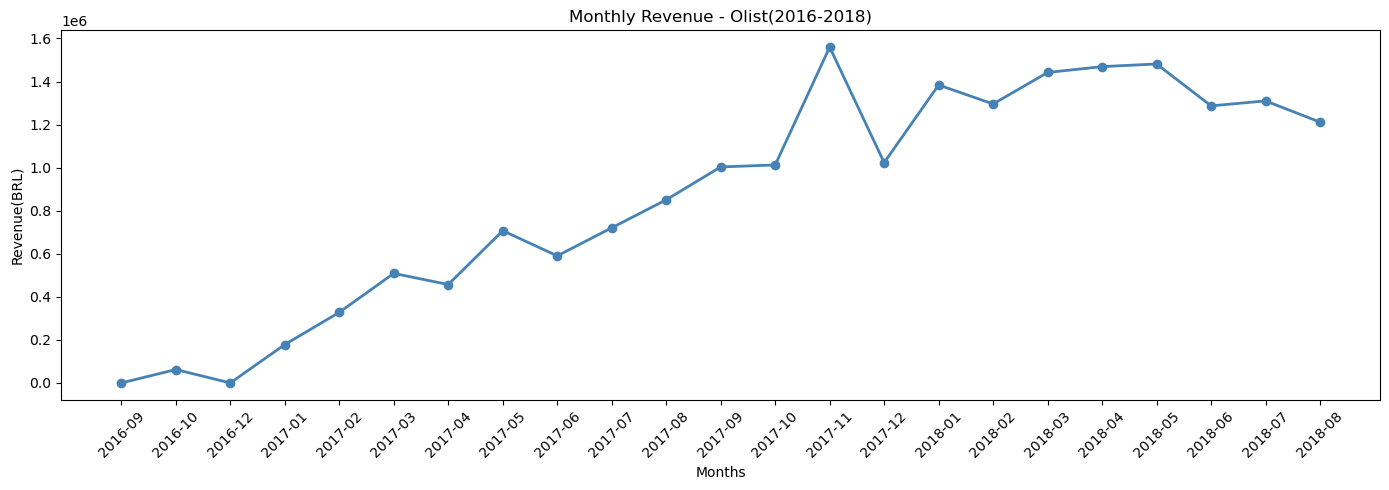

In [52]:
# CHART : Monthly Revenue Trend (2016-2018)

monthly_revenue_plot = monthly_revenue.reset_index()
monthly_revenue_plot.columns = ['Months','Revenue']
monthly_revenue_plot['Months'] = monthly_revenue_plot['Months'].astype(str)

plt.figure(figsize=(14,5))
plt.plot(
        monthly_revenue_plot['Months'],
        monthly_revenue_plot['Revenue'],
        marker = 'o', color = 'steelblue', linewidth=2)

plt.title('Monthly Revenue - Olist(2016-2018)')
plt.xlabel('Months')
plt.ylabel('Revenue(BRL)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight

Revenue grew from near zero in late 2016 to consistently above R$1M per month by mid-2018, demonstrating strong platform growth over the two-year period.

A clear spike is visible in **November 2017**, consistent with Black Friday — confirming that seasonal demand events have a significant impact on Olist's revenue. The sharp drop at the end of the chart reflects incomplete data for August 2018 rather than a genuine decline.

In [53]:
# Investigate the December 2016 low — was Olist just starting?
dec_2016 = delivered[
        (delivered['order_purchase_timestamp'].dt.year == 2016) &
        (delivered['order_purchase_timestamp'].dt.month == 12)
]
print('Orders in Dec 2016:', len(dec_2016))
print('Total_Revenue:', dec_2016['payment_value'].sum())

Orders in Dec 2016: 1
Total_Revenue: 19.62


In [54]:
# Top 10 categories by revenue
cat_revenue = delivered.groupby(
    delivered['product_category_name_english']
)['payment_value'].sum().nlargest(10)

print(cat_revenue)

product_category_name_english
bed_bath_table           1723932.14
health_beauty            1625923.50
computers_accessories    1563315.62
furniture_decor          1408110.04
watches_gifts            1388699.25
sports_leisure           1357249.46
housewares               1072820.85
auto                      835782.91
garden_tools              813055.77
cool_stuff                746763.39
Name: payment_value, dtype: float64


In [55]:
# Top 10 categories by number of orders
sales_cat = delivered.groupby(
    delivered['product_category_name_english']
)['order_id'].count().nlargest(10)

print(sales_cat)

product_category_name_english
bed_bath_table           11814
health_beauty             9816
sports_leisure            8791
furniture_decor           8643
computers_accessories     7963
housewares                7196
watches_gifts             6077
telephony                 4607
garden_tools              4480
auto                      4302
Name: order_id, dtype: int64


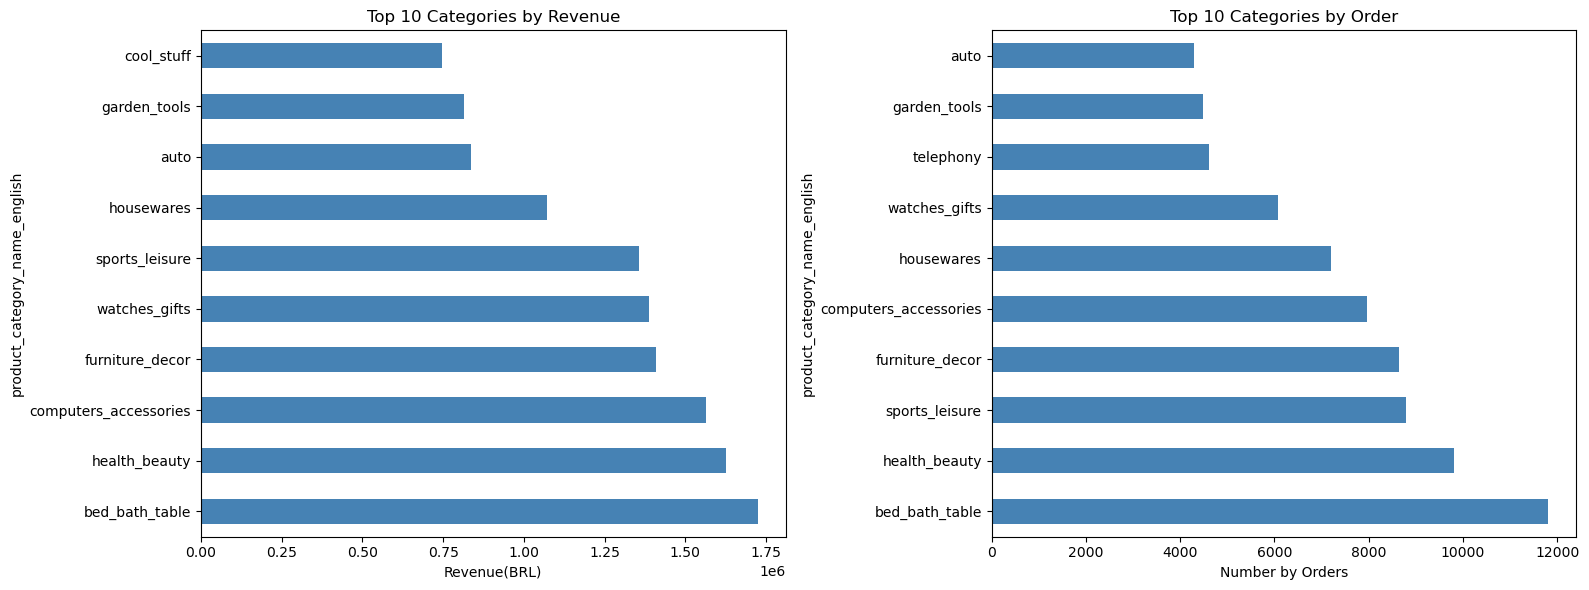

In [56]:
# CHART : Top 10 Categories by Revenue and by Orders

fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(16,6))

# Revenue Chart
cat_revenue.plot(kind= 'barh', ax=ax1, color= 'steelblue')
ax1.set_title('Top 10 Categories by Revenue')
ax1.set_xlabel('Revenue(BRL)')

# Order Chart
sales_cat.plot(kind= 'barh', ax=ax2, color= 'steelblue')
ax2.set_title('Top 10 Categories by Order')
ax2.set_xlabel('Number by Orders')

plt.tight_layout()
plt.show()

### Insight

**Bed, Bath & Table** leads in both revenue (approx. R$1.75M) and order volume (~12,000 orders), 
making it the dominant category on both dimensions.

**Health & Beauty** is a close second in revenue and orders — together these two categories 
represent the core of Olist's business volume.

Notably, **Computers & Accessories** ranks 3rd by revenue but drops to 5th by orders — 
indicating a significantly higher average order value compared to other categories. 
Conversely, **Sports & Leisure** ranks higher by orders than by revenue, suggesting 
lower-priced, high-frequency purchases.

This distinction matters for pricing and promotional strategy — high AOV categories like 
Computers benefit from targeted upselling, while high-volume categories like Sports & 
Leisure benefit more from frequency and retention campaigns.

In [58]:
# Key Revenue metrics
total_revenue = delivered['payment_value'].sum()
total_orders  = delivered['order_id'].nunique()

aov = total_revenue / total_orders

print(f'Total Revenue:       R$ {total_revenue:,.2f}')
print(f'Total Orders:        {total_orders:,}')
print(f'Average Order Value: R$ {aov:,.2f}')

Total Revenue:       R$ 19,881,945.07
Total Orders:        96,478
Average Order Value: R$ 206.08


In [60]:
# Payment Method breakdown
pay_type = delivered.groupby(
    delivered['payment_type']
)['order_id'].count().sort_values(ascending = False)

print('Payment Type most used: ', pay_type)

Payment Type most used:  payment_type
credit_card    85372
boleto         22505
voucher         6181
debit_card      1662
Name: order_id, dtype: int64


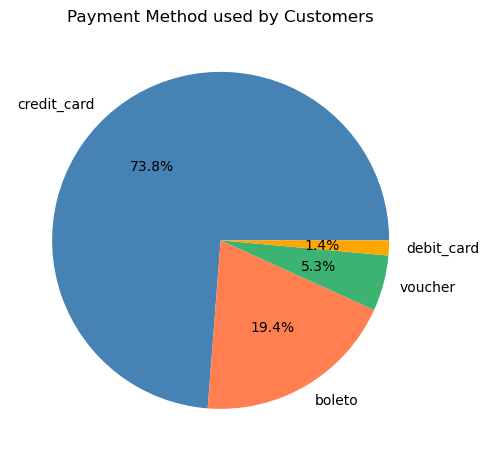

In [62]:
# CHART: Payment Methods

plt.figure(figsize=(5,5))
plt.pie(
    pay_type.values,
    labels = pay_type.index,
    autopct = '%1.1f%%',
    colors = ['steelblue' , 'coral', 'mediumseagreen', 'orange']
)
plt.title('Payment Method used by Customers')
plt.tight_layout()
plt.show()

### Insight

**Credit card** dominates at 73.8% of transactions, reflecting the preference of Brazil's banked population for instalment-based purchases.

**Boleto** accounts for 19.4% — this is a cash-based payment slip method widely used by Brazil's unbanked population. Nearly 1 in 5 customers cannot or does not use a card, representing a distinct customer segment that requires different promotional and payment strategies.

## 2. Delivery Performance

Delivery reliability is one of the most critical drivers of customer satisfaction in e-commerce. This section measures how often orders arrive late, by how many days, and the direct impact on review scores.

In [65]:
# Late Delivery Percentage

late_del = (delivered['delay_days'] > 0).sum() / total_orders *100
        
print(f'Late Delivery Rate:   {round(late_del, 2)}%')

Late Delivery Rate:   7.83%


In [66]:
# Number of Late Delivered Orders
late_orders = (delivered['delay_days'] > 0).sum()
print('Number of Late Orders: ', late_orders)

Number of Late Orders:  7558


In [67]:
# Average number of days late (for orders that were late)
avg_delay = delivered[delivered['delay_days'] > 0]['delay_days'].mean()
print ('Average day Late: ', round(avg_delay,2))

Average day Late:  10.57


In [68]:
# Review scores by delivery status
early_orders = delivered[delivered['delay_days'] < 0]['review_score'].mean()
ontime_orders = delivered[delivered['delay_days'] == 0]['review_score'].mean()
late_orders = delivered[delivered['delay_days'] > 0]['review_score'].mean()

print('Early delivery Average review: ', round(early_orders,2))
print('On-Time delivery Average review: ', round(ontime_orders,2))
print('Late delivery Average review: ', round(late_orders,2))

Early delivery Average review:  4.21
On-Time delivery Average review:  3.99
Late delivery Average review:  2.25


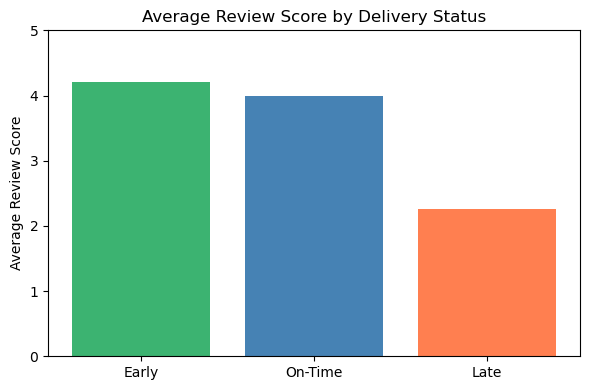

In [73]:
# CHART : Average Review Score by Delivery Status

plt.figure(figsize=(6,4))
plt.bar(['Early', 'On-Time', 'Late'],
        [early_orders, ontime_orders, late_orders],
         color = ['mediumseagreen', 'steelblue', 'coral'])

plt.title('Average Review Score by Delivery Status')
plt.ylabel('Average Review Score')
plt.ylim(0,5)
plt.tight_layout()
plt.show()

### Insight

**7.83% of orders are delivered late** — approximately 7,558 customers. When late, orders arrive an average of **10.57 days past the estimated date**, which is a significant deviation.

The impact on satisfaction is stark: late deliveries receive an average review score of **2.27** compared to **4.29 for early deliveries**. This is the single strongest driver of negative reviews on the platform.

Under-promising on delivery estimates (i.e. setting more conservative estimates) would be an immediate low-cost intervention to reduce late delivery counts.

## 3. Customer Satisfaction & Reviews

This section examines the overall distribution of review scores and identifies which product categories consistently receive the lowest ratings — creating churn risk despite potentially high order volumes.

In [27]:
# Worst Rated Categories

worst_rate_cat = delivered.groupby(
    delivered['product_category_name_english']
)['review_score'].mean().nsmallest(10)

print(worst_rate_cat)

product_category_name_english
security_and_services                2.500000
diapers_and_hygiene                  3.378378
office_furniture                     3.553204
home_comfort_2                       3.642857
fashion_male_clothing                3.649635
fixed_telephony                      3.756757
audio                                3.845333
furniture_mattress_and_upholstery    3.875000
party_supplies                       3.911111
bed_bath_table                       3.915276
Name: review_score, dtype: float64


### Insight

**Security & Services** is the worst rated category at 2.5 — likely driven by fulfillment issues on high-expectation, service-dependent products.

**Bed, Bath & Table** appears in both the **top 10 revenue categories** and the **worst rated categories** — high volume combined with poor reviews creates significant churn risk. Quality control or seller standards in this category should be a priority investigation.

In [80]:
# Overall review score distribution
review_dist = delivered['review_score'].value_counts().sort_index(ascending = False)
print(review_dist)

review_score
5.0    66046
4.0    22150
3.0     9649
2.0     3899
1.0    13118
Name: count, dtype: int64


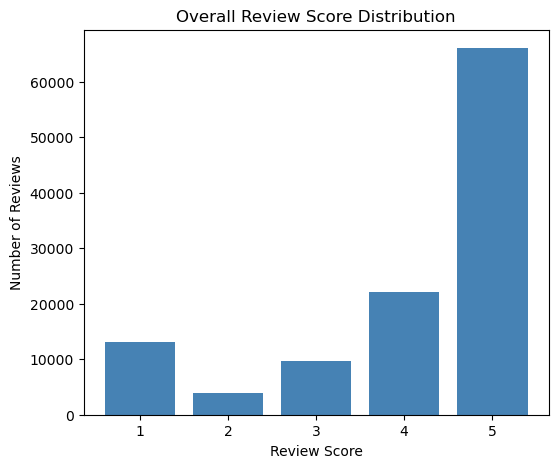

In [77]:
# CHART : Overall Review Distribution

review_dist = delivered['review_score'].value_counts().nlargest() 

plt.figure(figsize=(6,5))
plt.bar(review_dist.index, review_dist.values, color = 'steelblue')
plt.title('Overall Review Score Distribution')
plt.xlabel('Review Score')
plt.ylabel('Number of Reviews')
plt.show()

### Insight

The review distribution is **J-shaped** — heavily skewed toward 5 stars. **57% of customers give 5 stars**, followed by 4 stars reviews, indicating strong baseline satisfaction. However, **1-star reviews are the third most common score**, suggesting a polarised experience: most customers are happy, but a meaningful minority have very poor experiences likely linked to late delivery or product quality issues.

## 4. Geographic Insights

Brazil is a geographically vast country with significant infrastructure disparities between the developed south-east and the remote northern states. This section examines how revenue, customer concentration, and delivery performance vary by state.

In [81]:
# Top 10 states by customer count
cust_state = delivered.groupby(
    delivered['customer_state']
)['order_id'].count().nlargest(10)

print(cust_state)

customer_state
SP    48816
RJ    14963
MG    13496
RS     6431
PR     5894
SC     4239
BA     3950
DF     2447
GO     2395
ES     2318
Name: order_id, dtype: int64


In [83]:
# Top 10 states by revenue
rev_state = delivered.groupby(
    delivered['customer_state']
)['payment_value'].sum().nlargest(10)

print(rev_state.apply(lambda x: f'R$ {x:,.2f}'))

customer_state
SP    R$ 7,456,516.62
RJ    R$ 2,699,623.08
MG    R$ 2,290,457.39
RS    R$ 1,118,444.44
PR    R$ 1,036,003.69
BA      R$ 775,836.28
SC      R$ 769,234.50
GO      R$ 497,367.84
DF      R$ 424,872.44
ES      R$ 399,308.36
Name: payment_value, dtype: object


In [84]:
# States with worst average delivery times
avg_del_state = delivered.groupby(
    delivered['customer_state']
)['delivery_days'].mean().nlargest(10)

print(round(avg_del_state,2))

customer_state
RR    27.83
AP    27.66
AM    26.06
AL    24.13
PA    23.27
MA    21.19
SE    20.89
CE    20.34
AC    20.17
PB    20.11
Name: delivery_days, dtype: float64


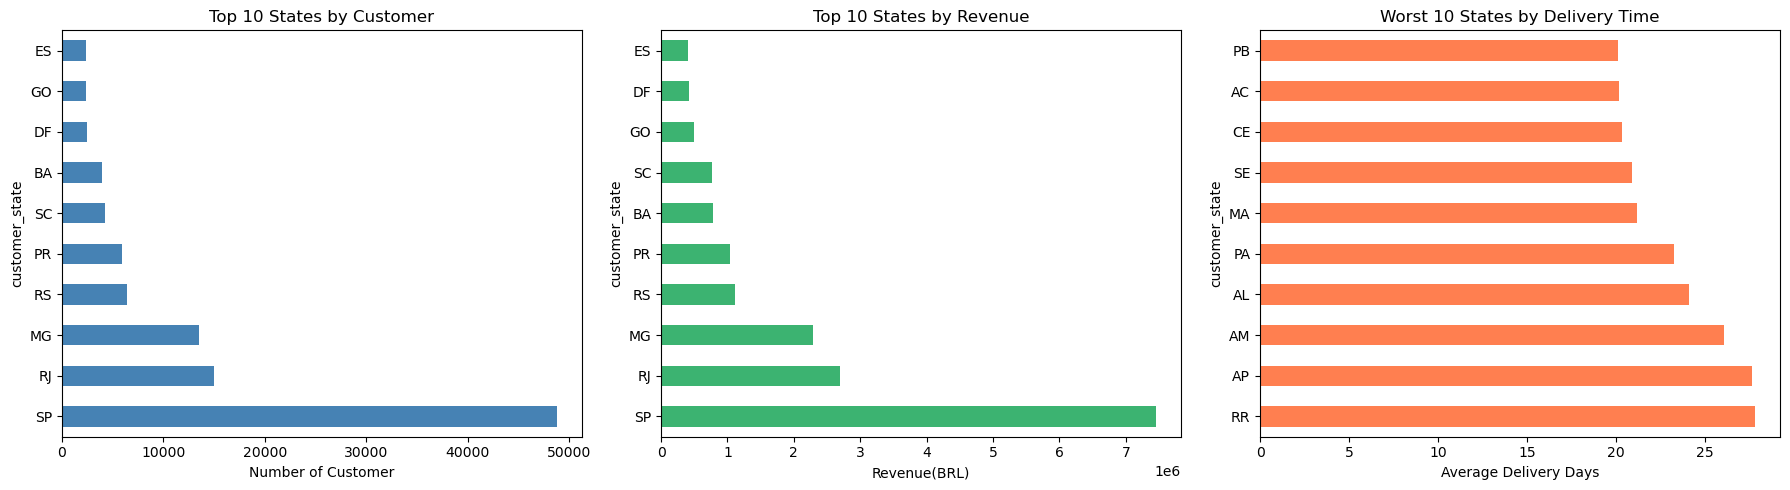

In [85]:
# CHART : Geographic Performance — Customers, Revenue, Delivery Time

fig, (ax1, ax2, ax3) = plt.subplots(1,3,figsize=(18,5))

#Customer by State
cust_state.plot(kind = 'barh', ax = ax1, color = 'steelblue')
ax1.set_title('Top 10 States by Customer')
ax1.set_xlabel('Number of Customer')

#Revenue by State
rev_state.plot(kind = 'barh', ax = ax2, color = 'mediumseagreen')
ax2.set_title('Top 10 States by Revenue')
ax2.set_xlabel('Revenue(BRL)')

#Customer by State
avg_del_state.plot(kind = 'barh', ax = ax3, color = 'coral')
ax3.set_title('Worst 10 States by Delivery Time')
ax3.set_xlabel('Average Delivery Days')

plt.tight_layout()
plt.show()

### Insight

**São Paulo (SP)** dominates on both Customers and Revenue — generating approximately 37% of total platform revenue and housing 49% of all customers. **Rio de Janeiro (RJ)** and **Minas Gerais (MG)** are distant second and third.

The states with the **worst delivery times are almost exclusively in the north** — Roraima (RR), Amapá (AP), and Amazonas (AM) averaging 26–28 days per delivery. This is more than double the national average, driven by poor road infrastructure and lack of logistics coverage.

These northern states also represent an **untapped growth opportunity** — low current revenue, but addressable with better logistics partnerships.

## Business Recommendations

Based on the full analysis of the Olist dataset, the following data-driven recommendations are proposed:

---

### 1. Capitalise on the Black Friday / November spike
November 2017 generated R$1.15M — a 53% jump from October. Olist should begin Black Friday preparation 30 days in advance: pre-negotiate courier capacity, increase warehouse stock for top categories (Health & Beauty, Bed Bath & Table), and launch omnichannel promotions.

---

### 2. Fix late delivery — it directly destroys reviews
7.83% late rate with an average 10.57 days beyond the estimate is unacceptable at scale. Two interventions: (1) **under-promise on delivery estimates** to increase the proportion of early/on-time deliveries, and (2) **expand logistics partnerships in northern states** where average delivery exceeds 27 days.

---

### 3. Investigate Bed, Bath & Table quality issues
This category appears in both top revenue and worst ratings — a dangerous combination. High volume with poor reviews drives churn. Olist should investigate seller quality standards and product descriptions in this category specifically.

---

### 4. Build boleto-friendly campaigns
19% of payments use boleto — Brazil's unbanked population is a real and significant segment. Boleto-exclusive discounts or extended payment windows could unlock incremental revenue from customers who cannot access credit.

---

### 5. Expand seller recruitment in northern states
RR, AP, AM, and AC have near-zero revenue despite having populations. The delivery problem is partly a supply problem — more local sellers mean shorter last-mile distances and faster delivery. Targeted seller acquisition in these states addresses both the revenue gap and the delivery time problem simultaneously.